In [1]:
import copy, random, re, time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
print(device)

cuda


In [2]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df["label"] = (df["sentiment"] == "positive").astype(int)

train_val, test_df = train_test_split(df, test_size=0.1, stratify=df["label"], random_state=SEED)
train_df, val_df = train_test_split(train_val, test_size=1 / 9, stratify=train_val["label"], random_state=SEED)
train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]

print(len(train_df), len(val_df), len(test_df))
print(train_df["label"].mean(), val_df["label"].mean(), test_df["label"].mean())

40000 5000 5000
0.5 0.5 0.5


## Токенизация, словарь, индексы

Токенизация: нижний регистр, удаление `<br />`, слова (буквы, цифры, апостроф) и знаки `!` и `?`, которые несут тональность.

В словарь попадают слова, встретившиеся в train не меньше 5 раз. Остальные слова, включая все слова, которых нет в train, получают индекс `<unk>`. Индекс `<pad>` равен 0, чтобы `padding_idx=0` в `nn.Embedding` совпадал с ним.

Отзывы длиннее `MAX_LEN` токенов обрезаются до первых `MAX_LEN`. Это ограничивает время обучения рекуррентных моделей.

In [3]:
TOKEN_RE = re.compile(r"[a-z0-9']+|[!?]")


def tokenize(text):
    return TOKEN_RE.findall(text.lower().replace("<br />", " "))


train_tokens = [tokenize(t) for t in train_df["review"]]
val_tokens = [tokenize(t) for t in val_df["review"]]
test_tokens = [tokenize(t) for t in test_df["review"]]

MIN_FREQ, MAX_LEN = 5, 400
counter = Counter(tok for toks in train_tokens for tok in toks)
itos = ["<pad>", "<unk>"] + [w for w, c in counter.most_common() if c >= MIN_FREQ]
stoi = {w: i for i, w in enumerate(itos)}
PAD, UNK = stoi["<pad>"], stoi["<unk>"]


def encode(tokens):
    return [stoi.get(t, UNK) for t in tokens[:MAX_LEN]] or [UNK]


train_ids = [encode(t) for t in train_tokens]
val_ids = [encode(t) for t in val_tokens]
test_ids = [encode(t) for t in test_tokens]

print("размер словаря:", len(itos))
print("доля <unk> в val:", np.mean([i == UNK for s in val_ids for i in s]))
print("длины train (токенов до обрезки):", pd.Series([len(t) for t in train_tokens]).describe().round(0).to_dict())

размер словаря: 38561
доля <unk> в val: 0.014648996823330221
длины train (токенов до обрезки): {'count': 40000.0, 'mean': 233.0, 'std': 172.0, 'min': 8.0, '25%': 128.0, '50%': 175.0, '75%': 282.0, 'max': 2503.0}


## Датасет и padding батчей

`collate` дополняет все отзывы батча до длины самого длинного индексом `<pad>` справа и возвращает **реальные длины** отдельным тензором. Они нужны, чтобы модель не принимала padding за часть отзыва.

In [4]:
class ReviewDataset(Dataset):
    def __init__(self, ids, labels):
        self.ids = [torch.tensor(s) for s in ids]
        self.labels = list(labels)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        return self.ids[i], self.labels[i]


def collate(batch):
    seqs, ys = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    x = pad_sequence(seqs, batch_first=True, padding_value=PAD)
    return x, lengths, torch.tensor(ys, dtype=torch.float)


BATCH = 64
train_loader = DataLoader(ReviewDataset(train_ids, train_df["label"]), BATCH, shuffle=True, collate_fn=collate)
val_loader = DataLoader(ReviewDataset(val_ids, val_df["label"]), 256, collate_fn=collate)
test_loader = DataLoader(ReviewDataset(test_ids, test_df["label"]), 256, collate_fn=collate)

x, lengths, y = next(iter(train_loader))
print(x.shape, lengths[:8], y[:8])

torch.Size([64, 400]) tensor([339, 120, 245, 263, 400, 169, 258, 179]) tensor([1., 1., 0., 0., 0., 0., 0., 1.])


## Модели

Все модели получают пару `(x, lengths)` и возвращают один логит на отзыв (0 соответствует вероятности 0.5, положительное значение означает «положительный отзыв»).

* `MeanEmbeddingClassifier` — среднее embeddings по реальным токенам (padding исключён маской), затем линейный слой. Порядок слов не учитывается.
* `RecurrentClassifier` — embedding с `padding_idx`, затем `nn.RNN`, `nn.LSTM` или `nn.GRU`, затем линейный слой по последнему скрытому состоянию.

Последнее скрытое состояние выбирается через `pack_padded_sequence`: рекуррентный слой для каждого отзыва останавливается на его реальной длине, и `h_n` — это состояние после последнего настоящего токена. При `use_packing=False` слой пройдёт и по `<pad>`, и состояние `h_n` будет после padding. Этот вариант нужен только для демонстрации.

In [5]:
EMB_DIM, HID_DIM = 128, 128


class MeanEmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, EMB_DIM, padding_idx=PAD)
        self.fc = nn.Linear(EMB_DIM, 1)

    def forward(self, x, lengths):
        mask = (x != PAD).unsqueeze(-1)
        mean = (self.emb(x) * mask).sum(1) / lengths.to(x.device).unsqueeze(1)
        return self.fc(mean).squeeze(1)


class RecurrentClassifier(nn.Module):
    def __init__(self, vocab_size, cell, use_packing=True):
        super().__init__()
        self.use_packing = use_packing
        self.emb = nn.Embedding(vocab_size, EMB_DIM, padding_idx=PAD)
        self.rnn = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell](EMB_DIM, HID_DIM, batch_first=True)
        self.fc = nn.Linear(HID_DIM, 1)

    def forward(self, x, lengths):
        e = self.emb(x)
        if self.use_packing:
            e = pack_padded_sequence(e, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h = self.rnn(e)
        if isinstance(h, tuple):
            h = h[0]
        return self.fc(h[-1]).squeeze(1)


V = len(itos)
factories = {
    "Mean embeddings": lambda: MeanEmbeddingClassifier(V),
    "RNN": lambda: RecurrentClassifier(V, "rnn"),
    "LSTM": lambda: RecurrentClassifier(V, "lstm"),
    "GRU": lambda: RecurrentClassifier(V, "gru"),
    "GRU без packing": lambda: RecurrentClassifier(V, "gru", use_packing=False),
}

## Обучение

Функция потерь `BCEWithLogitsLoss`, оптимизатор Adam, gradient clipping по норме 1.0 (если норма градиента больше 1, весь градиент масштабируется до нормы 1; это защищает рекуррентные сети от взрыва градиента). Одинаковые данные, seed и гиперпараметры у всех моделей. После обучения загружаются веса эпохи с лучшей accuracy на validation. Время обучения считается только по шагам обучения, без оценки на validation.

In [6]:
EPOCHS, LR, CLIP = 5, 1e-3, 1.0
criterion = nn.BCEWithLogitsLoss(reduction="sum")


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    logits, ys = [], []
    for x, lengths, y in loader:
        logits.append(model(x.to(device), lengths).cpu())
        ys.append(y)
    logits, ys = torch.cat(logits), torch.cat(ys)
    loss = criterion(logits, ys).item() / len(ys)
    probs = torch.sigmoid(logits).numpy()
    acc = ((probs > 0.5) == ys.numpy()).mean()
    return loss, acc, probs


def fit(name):
    set_seed()
    model = factories[name]().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc"]}
    best_acc, best_state, best_epoch, train_time = -1, None, 0, 0.0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        t0 = time.perf_counter()
        total_loss, correct, n = 0.0, 0, 0
        for x, lengths, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x, lengths)
            loss = criterion(logits, y) / len(y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            opt.step()
            total_loss += loss.item() * len(y)
            correct += ((logits > 0) == (y > 0.5)).sum().item()
            n += len(y)
        if device.type == "cuda":
            torch.cuda.synchronize()
        train_time += time.perf_counter() - t0

        val_loss, val_acc, _ = evaluate(model, val_loader)
        for k, v in zip(hist, [total_loss / n, correct / n, val_loss, val_acc]):
            hist[k].append(v)
        if val_acc > best_acc:
            best_acc, best_epoch, best_state = val_acc, epoch, copy.deepcopy(model.state_dict())
        print(f"{name:16s} epoch {epoch}: train loss {hist['train_loss'][-1]:.4f} acc {hist['train_acc'][-1]:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f}")

    model.load_state_dict(best_state)
    _, _, val_probs = evaluate(model, val_loader)
    return dict(model=model, hist=hist, train_time=train_time, best_epoch=best_epoch, val_probs=val_probs)


results = {name: fit(name) for name in factories}

Mean embeddings  epoch 1: train loss 0.5647 acc 0.7466 | val loss 0.4183 acc 0.8346
Mean embeddings  epoch 2: train loss 0.3350 acc 0.8722 | val loss 0.3113 acc 0.8760
Mean embeddings  epoch 3: train loss 0.2559 acc 0.9046 | val loss 0.2754 acc 0.8942
Mean embeddings  epoch 4: train loss 0.2145 acc 0.9220 | val loss 0.2604 acc 0.9006
Mean embeddings  epoch 5: train loss 0.1856 acc 0.9349 | val loss 0.2549 acc 0.9060
RNN              epoch 1: train loss 0.6282 acc 0.6483 | val loss 0.5663 acc 0.7200
RNN              epoch 2: train loss 0.5251 acc 0.7538 | val loss 0.5024 acc 0.7768
RNN              epoch 3: train loss 0.4632 acc 0.7924 | val loss 0.4842 acc 0.7742
RNN              epoch 4: train loss 0.4041 acc 0.8289 | val loss 0.4832 acc 0.7730
RNN              epoch 5: train loss 0.3522 acc 0.8557 | val loss 0.4501 acc 0.8014
LSTM             epoch 1: train loss 0.5529 acc 0.7175 | val loss 0.5565 acc 0.7744
LSTM             epoch 2: train loss 0.3735 acc 0.8435 | val loss 0.3679 acc

## Сравнение: качество, время, параметры

In [7]:
val_y = val_df["label"].values
rows = []
for name, r in results.items():
    pred = (r["val_probs"] > 0.5).astype(int)
    rows.append({
        "Модель": name,
        "Val accuracy": accuracy_score(val_y, pred),
        "Val F1": f1_score(val_y, pred),
        "Лучшая эпоха": r["best_epoch"],
        "Параметры": sum(p.numel() for p in r["model"].parameters()),
        "Время обучения, с": r["train_time"],
        "Секунд на эпоху": r["train_time"] / EPOCHS,
    })
table = pd.DataFrame(rows).set_index("Модель")
table.style.format({"Val accuracy": "{:.4f}", "Val F1": "{:.4f}", "Параметры": "{:,}",
                    "Время обучения, с": "{:.0f}", "Секунд на эпоху": "{:.0f}"})

,Val accuracy,Val F1,Лучшая эпоха,Параметры,"Время обучения, с",Секунд на эпоху
Модель,,,,,,
Mean embeddings,0.9060,0.9042,5,"4,935,937",14,3
RNN,0.8014,0.8025,5,"4,968,961",65,13
LSTM,0.8948,0.8949,5,"5,068,033",68,14
GRU,0.9046,0.9036,3,"5,035,009",67,13
GRU без packing,0.8846,0.8858,5,"5,035,009",29,6


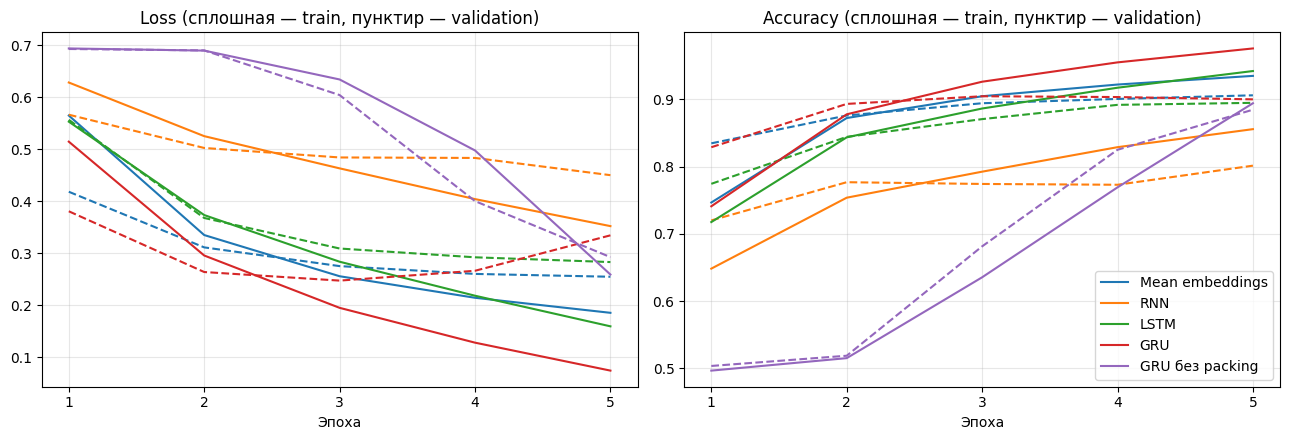

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = plt.cm.tab10.colors
for (name, r), c in zip(results.items(), colors):
    ep = range(1, EPOCHS + 1)
    axes[0].plot(ep, r["hist"]["train_loss"], color=c, label=name)
    axes[0].plot(ep, r["hist"]["val_loss"], color=c, ls="--")
    axes[1].plot(ep, r["hist"]["train_acc"], color=c, label=name)
    axes[1].plot(ep, r["hist"]["val_acc"], color=c, ls="--")
axes[0].set_title("Loss (сплошная — train, пунктир — validation)")
axes[1].set_title("Accuracy (сплошная — train, пунктир — validation)")
for ax in axes:
    ax.set_xlabel("Эпоха")
    ax.set_xticks(range(1, EPOCHS + 1))
    ax.grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

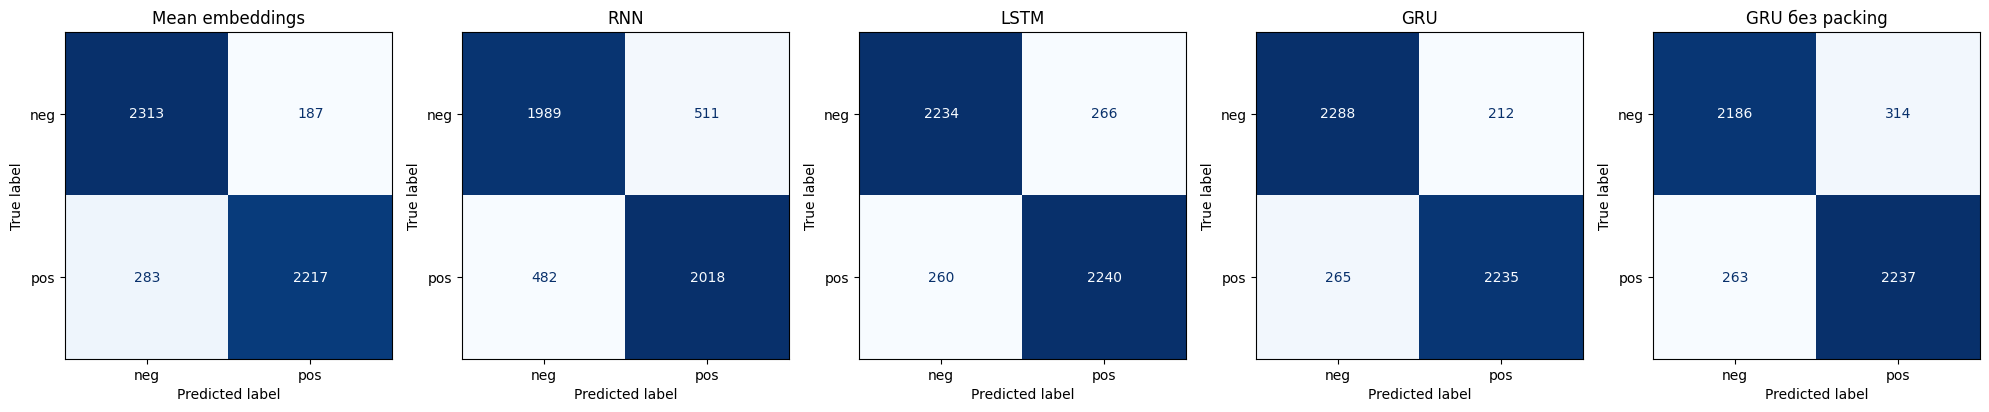

In [9]:
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
for ax, (name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        val_y, (r["val_probs"] > 0.5).astype(int), display_labels=["neg", "pos"],
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Короткие, длинные и ошибочные отзывы

Границы групп — 1/3 и 2/3 квантили реальной длины отзыва в train (в токенах, до обрезки): короткие, средние, длинные. Те же границы применяются к validation и позже к test.

In [10]:
real_len = lambda toks: np.array([len(t) for t in toks])
edges = np.quantile(real_len(train_tokens), [1 / 3, 2 / 3])
bucket_names = np.array(["короткие", "средние", "длинные"])
val_bucket = bucket_names[np.digitize(real_len(val_tokens), edges)]
print("границы (токенов):", edges.round(0), "| отзывов в группах:", dict(pd.Series(val_bucket).value_counts()))

by_len = pd.DataFrame({
    name: pd.Series(((r["val_probs"] > 0.5) == val_y)).groupby(val_bucket).mean()
    for name, r in results.items()
}).loc[bucket_names].T
by_len.style.format("{:.4f}")

границы (токенов): [140. 233.] | отзывов в группах: {'средние': np.int64(1724), 'длинные': np.int64(1647), 'короткие': np.int64(1629)}


,короткие,средние,длинные
Mean embeddings,0.9190,0.9014,0.8980
RNN,0.8398,0.8016,0.7632
LSTM,0.9061,0.8956,0.8828
GRU,0.9134,0.9008,0.8998
GRU без packing,0.9055,0.8828,0.8658


Длинные отзывы обрезаются. Возможно, из-за этого небольшая потеря

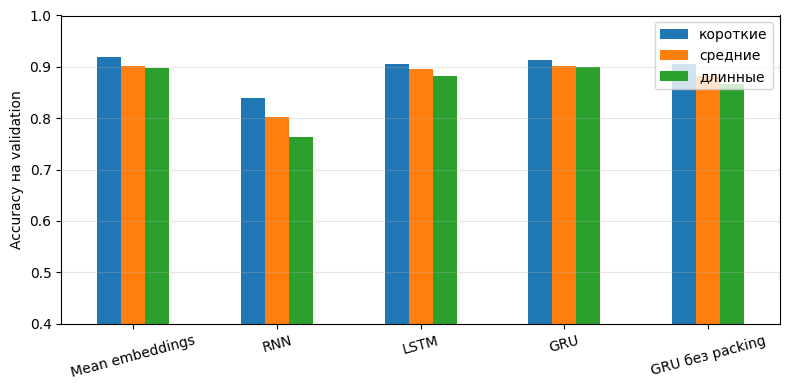

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
by_len.plot.bar(ax=ax, rot=15)
ax.set_ylabel("Accuracy на validation")
ax.set_ylim(0.4, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Выбранная модель — модель с лучшей accuracy на validation среди моделей с корректной обработкой padding (вариант «без packing» в выбор не входит). Ниже её ошибки на validation: самые короткие, самые длинные и самые уверенные.

In [12]:
candidates = [n for n in results if "без packing" not in n]
chosen = max(candidates, key=lambda n: table.loc[n, "Val accuracy"])
print("выбрана модель:", chosen)

probs = results[chosen]["val_probs"]
errors = pd.DataFrame({
    "tokens": real_len(val_tokens),
    "true": val_y,
    "p_pos": probs.round(3),
    "review": val_df["review"].str.replace("<br />", " ").str.slice(0, 350),
})[(probs > 0.5) != val_y]
errors["confidence"] = np.abs(errors["p_pos"] - 0.5) * 2
print("ошибок:", len(errors), "из", len(val_y))

pd.set_option("display.max_colwidth", 350)
for title, part in [("Самые короткие", errors.nsmallest(4, "tokens")),
                    ("Самые длинные", errors.nlargest(4, "tokens")),
                    ("Самые уверенные", errors.nlargest(4, "confidence"))]:
    print("\n==", title)
    display(part[["tokens", "true", "p_pos", "review"]])

выбрана модель: Mean embeddings
ошибок: 470 из 5000

== Самые короткие


,tokens,true,p_pos,review
1658,13,0,0.988,Ming The Merciless does a little Bardwork and a movie most foul!
4705,31,0,0.614,"My first thoughts on this film were of using science fiction as a bad way to show naked women, althought not a brilliant story line it had quite a good ending"
2539,32,1,0.012,"The movie was a big Car Commercial. :-) But who cares? I went to the theater to view the Shelby Cobra, Angelina & Cage. So I guess it was a good movie. *bg*"
4078,44,0,0.671,"(mild spoilers) This movie was filthy and stupid. It could have done well without the constant humping and nude sex. It was also very profane. I think that they had a good story developing, but they messed up the whole thing by overdoing it."



== Самые длинные


,tokens,true,p_pos,review
178,2124,1,0.144,"(Some spoilers included:) Although, many commentators have called this film surreal, the term fits poorly here. To quote from Encyclopedia Britannica's, surreal means: ""Fantastic or incongruous imagery"": One needn't explain to the unimaginative how many ways a plucky ten-year-old boy at large and seeking his fortune in the driver's seat of a ..."
2983,1016,1,0.236,"While the original 1932 version, with Preston Foster, was good, there's no remake more worthy than this 1959 one, or more impossible to find anywhere, just as I strongly suspect Mickey Rooney to have had something to do with that. Never could a mere performance have ever been so masterfully brilliant, or a script more thought-provoking, as well..."
824,1006,1,0.295,"""Buffalo Bill, Hero of the Far West"" director Mario Costa's unsavory Spaghetti western ""The Beast"" with Klaus Kinski could only have been produced in Europe. Hollywood would never dared to have made a western about a sexual predator on the prowl as the protagonist of a movie. Never mind that Kinski is ideally suited to the role of 'Crazy' Johnn..."
1755,987,1,0.259,"Beat a path to this important documentary that looks like an attractive feature. Forbidden Lie$(2007) is simply a better (cinematic) version of Norma Khouri's book Forbidden Love, and THAT was a best-seller. An onion-peeling of literary fraud and of a pretty woman, Lie$ is the very best in editorialised reality TV. Cleverly edited and colourfu..."



== Самые уверенные


,tokens,true,p_pos,review
115,116,1,0.0,"This movie has everything that makes a bad movie worth watching - sloppy editing, little to no continuity, insane dialog, bad (you might even say non-existent) acting, pointless story lines, shots that go on FAR too long...and it's perfect for MST3K-style riffing, not to mention the ""Corpse Eaters Drinking Game"": Scribble on forms...take a shot..."
904,99,1,0.0,"This would have worked a lot better if it had been made as ""Mitchell in Malta."" At least then we would have been spared the sight of Joe Don Baker running around an otherwise scenic Mediterranean locale clad in that ridiculous looking cowboy outfit...not to mention acting like an Old West gunslinger. Mitchell being Mitchell, the film wouldn't h..."
2276,129,1,0.0,black tar can't be snorted there's a documentary: dark end of the street about s.f. street punks and b.t. abuse - not bad - quite heavy. in wasted there's this stuff that looks like coke but should be something else... no big deal. black tar can't be snorted there's a documentary: dark end of the street about s.f. street punks and b.t. abuse - ...
4398,107,1,0.0,"This flick is sterling example of the state of erotic B-movies: bad porn movies without the hardcore sex. The plot in this one isn't so bad as these things go; it involves a female lawyer trying to prove her lover is innocent of killing his wife. The rest of the movie, however, leaves something to be desired. Bad acting, bad direction, bad look..."


Разметка выглядит довольно странной в некоторых местах, можно поспорить. Любопытно, какое для датасета согласие разметчиков (гуглить его я не буду).

## Влияние padding и длины на предсказание

Проверка: берём короткий отзыв из validation и предсказываем вероятность дважды — одного, и в батче вместе с самым длинным отзывом (тогда короткий дополняется `<pad>` до длины длинного). Корректная модель должна дать одну и ту же вероятность. У GRU без packing она меняется: состояние `h_n` берётся после сотен `<pad>`-шагов.

In [13]:
@torch.no_grad()
def predict(model, seqs):
    model.eval()
    x, lengths, _ = collate([(torch.tensor(s), 0) for s in seqs])
    return torch.sigmoid(model(x.to(device), lengths)).cpu().numpy()


short_i = int(np.argmin([len(s) for s in val_ids]))
long_i = int(np.argmax([len(s) for s in val_ids]))
print("длина короткого отзыва:", len(val_ids[short_i]), "| длина длинного:", len(val_ids[long_i]))

demo = pd.DataFrame({
    name: [predict(results[name]["model"], [val_ids[short_i]])[0],
           predict(results[name]["model"], [val_ids[short_i], val_ids[long_i]])[0]]
    for name in ["Mean embeddings", "GRU", "GRU без packing"]
}, index=["один", "в батче с длинным"]).T
demo["разница"] = (demo["один"] - demo["в батче с длинным"]).abs()
demo.style.format("{:.4f}")

длина короткого отзыва: 13 | длина длинного: 400


,один,в батче с длинным,разница
Mean embeddings,0.9885,0.9885,0.0000
GRU,0.8476,0.8476,0.0000
GRU без packing,0.7206,0.9287,0.2081


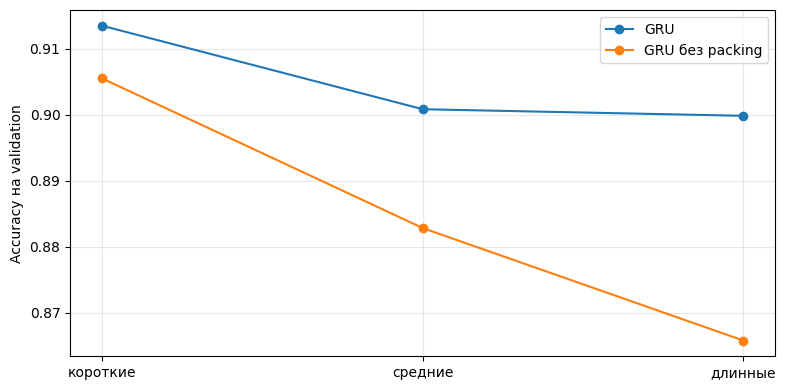

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
for name in ["GRU", "GRU без packing"]:
    ax.plot(by_len.columns, by_len.loc[name], marker="o", label=name)
ax.set_ylabel("Accuracy на validation")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Единственная оценка выбранной модели на test.

Mean embeddings: test accuracy 0.8976, F1 0.8957, loss 0.2461


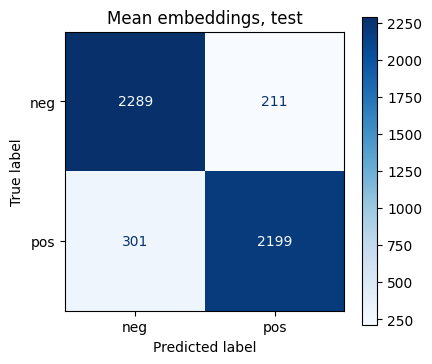

короткие    0.9007
средние     0.9055
длинные     0.8866


In [15]:
test_y = test_df["label"].values
test_loss, test_acc, test_probs = evaluate(results[chosen]["model"], test_loader)
test_pred = (test_probs > 0.5).astype(int)
print(f"{chosen}: test accuracy {test_acc:.4f}, F1 {f1_score(test_y, test_pred):.4f}, loss {test_loss:.4f}")

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(test_y, test_pred, display_labels=["neg", "pos"], ax=ax, cmap="Blues")
ax.set_title(f"{chosen}, test")
plt.show()

test_bucket = bucket_names[np.digitize(real_len(test_tokens), edges)]
print(pd.Series(test_pred == test_y).groupby(test_bucket).mean().loc[bucket_names].round(4).to_string())

## Как padding, длина и последнее состояние влияют на предсказание

**Padding.** Батч — прямоугольный тензор, поэтому короткие отзывы дополняются индексом `<pad>`. Пример: батч из отзывов длины 3 и 5, длина строки 5. Первая строка: `[w1, w2, w3, <pad>, <pad>]`.

**Реальная длина.** Вектор `lengths = [3, 5]` говорит модели, где кончается отзыв. Без него модель не отличит `<pad>` от слова.

**Последнее состояние.** Рекуррентный слой на каждом шаге обновляет скрытое состояние: `h1, h2, h3, ...`. Для отзыва из трёх токенов содержательное состояние — `h3`.
* Без `lengths` слой прошёл бы ещё два шага по `<pad>` и вернул `h5`. Эти два шага сдвигают состояние: у RNN и GRU информация о настоящих словах постепенно затирается (у RNN быстрее, у GRU и LSTM затворы могут её сохранять). `padding_idx` делает вектор `<pad>` нулевым, но нулевой вход всё равно меняет состояние через смещение и рекуррентную матрицу. Чем короче отзыв внутри батча с длинными, тем больше таких шагов и тем сильнее искажение. Предсказание тогда зависит от того, какие соседи оказались в батче; это проверено в разделе 8.
* С `pack_padded_sequence` слой для каждой строки останавливается на её реальной длине, и `h_n` — это `h3` для первой строки и `h5` для второй. Предсказание не зависит от соседей по батчу.

**Длина отзыва.** Для рекуррентной сети длинный отзыв — длинная цепочка шагов, по которой градиент проходит назад, затухая. У обычной RNN это хуже всего (влияние начала отзыва на ответ быстро исчезает), у LSTM и GRU затворы смягчают проблему. Gradient clipping защищает от обратной проблемы — взрыва градиента. Модель на усреднённых embeddings от длины не зависит по построению, но не видит порядка слов, поэтому не различает «not good» и «good, not bad» так, как последовательная модель.

Конкретные значения accuracy, времени и числа параметров — в таблице раздела 6, по группам длины — в разделе 7.